# CREDIT CARD FRAUD DETECTION USING MACHINE LEARNING

## Objective

In this project, I built a machine learning model to identify fraudulent credit card transactions. Since fraud cases are very few compared to genuine transactions, I balanced the data before training the models. Finally, I compared the performance of Logistic Regression and Random Forest using different evaluation metrics. 

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [37]:
df = pd.read_csv("D:/CodeSoft/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [38]:
print("Rows and Columns :", df.shape)

Rows and Columns : (284807, 31)


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [40]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [41]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [42]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 1081


In [43]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [44]:
df = df.drop_duplicates()
print(df.shape)

(283726, 31)


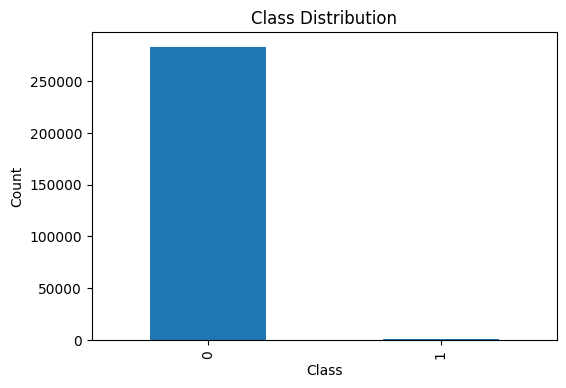

In [13]:
plt.figure(figsize=(6,4))
df["Class"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

### Analysis:  
This graph shows the number of genuine and fraudulent transactions in the dataset. It can be seen that Class 0 (Genuine) has a very large number of records, while Class 1 (Fraud) has only a few transactions. This means the dataset is highly imbalanced. If this imbalance is not handled properly, the model may become biased towards predicting genuine transactions. Because of this, balancing the dataset before training the model was an important step.

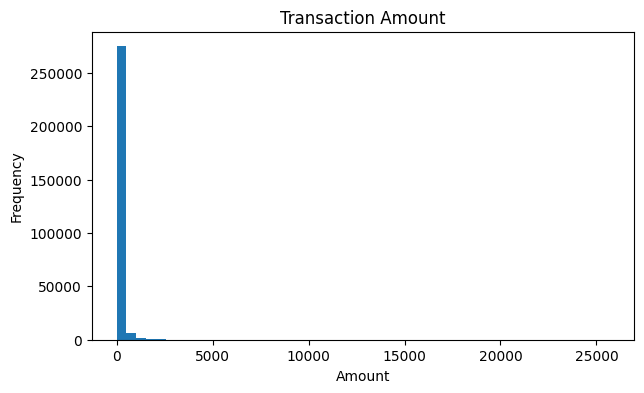

In [14]:
plt.figure(figsize=(7,4))
plt.hist(df["Amount"], bins=50)

plt.title("Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

### Analysis:  
The histogram shows that most transactions have a small transaction amount, while only a few transactions have very large amounts. This creates a right-skewed distribution. The graph suggests that customers usually make small payments, and high-value transactions occur less frequently. This type of distribution is common in financial transaction datasets.

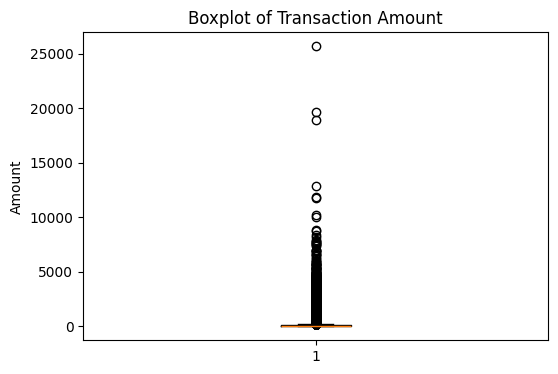

In [15]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Amount"])
plt.title("Boxplot of Transaction Amount")
plt.ylabel("Amount")
plt.show()

### Analysis: 
The boxplot shows that most transaction amounts are concentrated in the lower range. There are many points above the upper whisker, which represent outliers. These outliers are transactions with unusually high amounts. Such values are expected in financial data and may include both genuine and fraudulent transactions. Instead of removing them, they were kept because they can provide useful information for fraud detection.

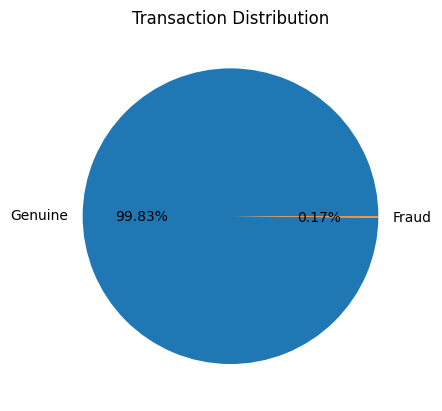

In [16]:
df["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    labels=["Genuine","Fraud"]
)
plt.title("Transaction Distribution")
plt.ylabel("")
plt.show()

### Analysis:  
The pie chart clearly shows that 99.83% of the transactions are genuine, while only 0.17% are fraudulent. This again confirms that fraud cases are very rare compared to normal transactions. Due to this imbalance, the dataset needed to be balanced before training the machine learning models.

In [18]:
scaler = StandardScaler()

df["Time"] = scaler.fit_transform(df[["Time"]])
df["Amount"] = scaler.fit_transform(df[["Amount"]])

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0


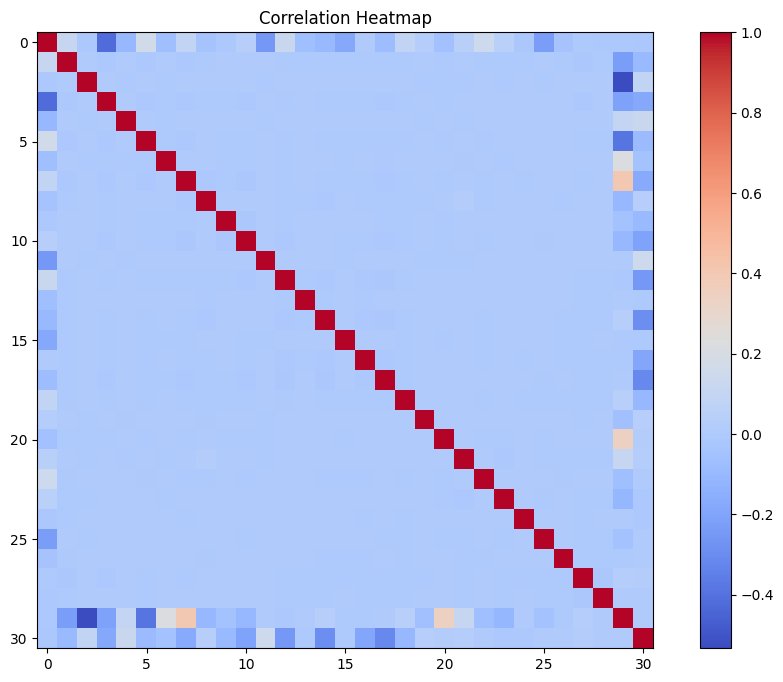

In [19]:
plt.figure(figsize=(12,8))
plt.imshow(df.corr(), cmap="coolwarm")
plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

### Analysis:  
The heatmap shows the correlation between all numerical features in the dataset. Most feature pairs have values close to zero, which means they are not strongly related to each other. Only a few features have a slightly positive or negative correlation. This indicates that the dataset contains different types of information, which can help the machine learning models make better predictions.

In [20]:
fraud = df[df["Class"] == 1]
genuine = df[df["Class"] == 0]

print("Fraud :", len(fraud))
print("Genuine :", len(genuine))

Fraud : 473
Genuine : 283253


In [21]:
genuine_sample = genuine.sample(n=len(fraud), random_state=42)
new_data = pd.concat([genuine_sample, fraud])
new_data = new_data.sample(frac=1, random_state=42)

new_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
126265,-0.354691,1.222435,-0.482973,1.006126,-0.629278,-1.545401,-1.058787,-0.699653,0.058106,2.098220,...,-0.013621,0.112532,0.028354,0.681553,0.389823,-0.700175,0.081159,0.034358,-0.349333,0
125569,-0.359956,1.372852,-0.600069,-1.982242,-1.652596,1.875989,2.850328,-0.650839,0.633996,-1.195478,...,0.085969,-0.090311,-0.211467,0.957720,0.811915,-0.137130,-0.013380,0.031342,-0.074612,0
182992,0.648700,1.889618,1.073099,-1.678018,4.173268,1.015516,-0.009389,-0.079706,0.064071,-0.714517,...,0.203728,0.733796,-0.036560,0.334306,0.147171,0.279556,0.031669,0.035883,-0.340467,1
271257,1.467492,0.039062,0.889239,0.302199,-0.585161,0.431838,-1.116524,1.050711,-0.232965,-0.109813,...,-0.253421,-0.535450,0.072419,0.050588,-0.475029,0.136236,0.248946,0.098623,-0.329405,0
230281,1.083717,-0.629286,1.379787,-0.297018,-1.393297,1.489655,-0.885139,1.872444,-0.523914,-0.590964,...,0.158709,0.782369,-0.492603,0.834802,0.546616,0.155325,0.091849,0.002683,-0.323095,0


In [22]:
print(new_data["Class"].value_counts())

Class
0    473
1    473
Name: count, dtype: int64


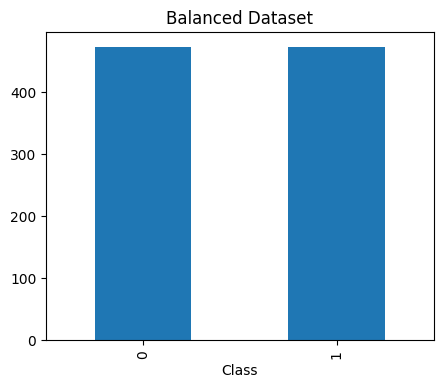

In [23]:
plt.figure(figsize=(5,4))
new_data["Class"].value_counts().plot(kind="bar")

plt.title("Balanced Dataset")
plt.show()

### Analysis:  
This graph shows the dataset after balancing. Both Class 0 and Class 1 now have an equal number of samples. Balancing the dataset helps reduce bias during training and gives the model a better chance to learn the characteristics of fraudulent transactions instead of mostly predicting genuine ones.

In [24]:
X = new_data.drop("Class", axis=1)
y = new_data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(756, 30)
(190, 30)


In [25]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [26]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision :", precision_score(y_test, lr_pred))
print("Recall :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Accuracy : 0.9421052631578948
Precision : 0.9743589743589743
Recall : 0.8941176470588236
F1 Score : 0.9325153374233128


In [27]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       105
           1       0.97      0.89      0.93        85

    accuracy                           0.94       190
   macro avg       0.95      0.94      0.94       190
weighted avg       0.94      0.94      0.94       190



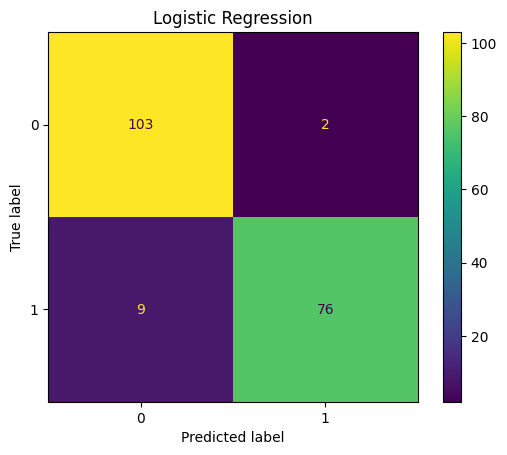

In [28]:
cm = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm).plot()

plt.title("Logistic Regression")
plt.show()

### Analysis:  
The confusion matrix shows that the Logistic Regression model correctly classified 103 genuine transactions and 76 fraudulent transactions. It incorrectly predicted 2 genuine transactions as fraud and missed 9 fraud cases by predicting them as genuine. Overall, the model performed well, but it still failed to detect some fraudulent transactions.

In [29]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [30]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.9473684210526315
Precision : 1.0
Recall : 0.8823529411764706
F1 Score : 0.9375


In [31]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       105
           1       1.00      0.88      0.94        85

    accuracy                           0.95       190
   macro avg       0.96      0.94      0.95       190
weighted avg       0.95      0.95      0.95       190



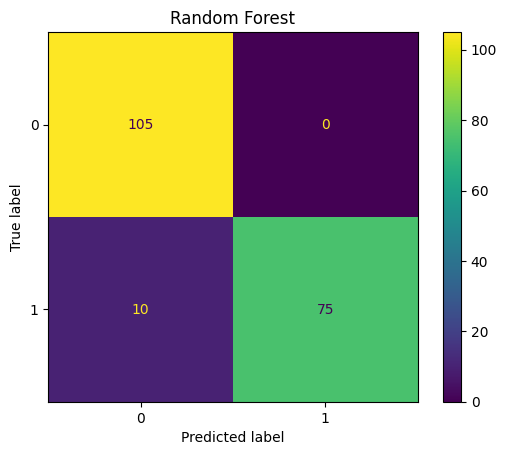

In [32]:
cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm).plot()

plt.title("Random Forest")
plt.show()

### Analysis:  
The Random Forest model correctly classified 105 genuine transactions and 75 fraudulent transactions. It did not wrongly classify any genuine transaction as fraud, but it missed 10 fraudulent transactions. This shows that Random Forest achieved very high accuracy and precision, although it still failed to identify a few fraud cases.

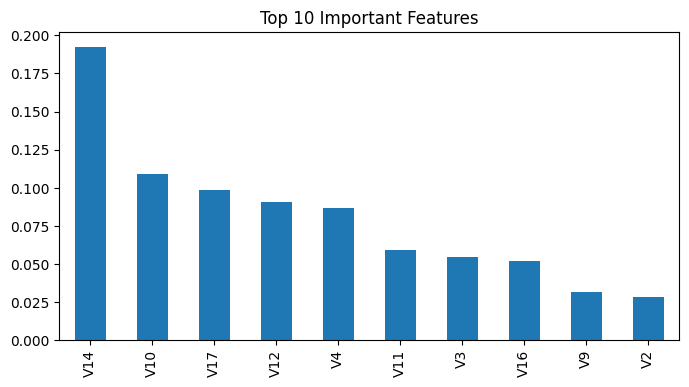

In [35]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Top 10 Important Features")
plt.show()

### Analysis:  
This graph shows the ten most important features used by the Random Forest model for making predictions. Among them, V14 has the highest importance, followed by V10, V17, V12, and V4. These features contributed the most to distinguishing fraudulent and genuine transactions. Features with higher importance had a greater impact on the model's decisions.

In [33]:
result = pd.DataFrame({

    "Model":["Logistic Regression","Random Forest"],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]

})

result

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.942105,0.974359,0.894118,0.932515
1,Random Forest,0.947368,1.000000,0.882353,0.937500


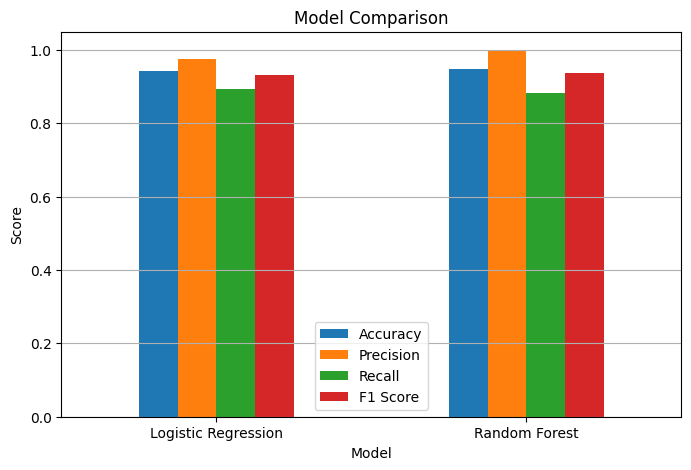

In [34]:
result.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

### Analysis:   
This graph compares the performance of Logistic Regression and Random Forest using Accuracy, Precision, Recall, and F1-score. Both models achieved good results, but Random Forest performed slightly better in terms of accuracy and precision. Logistic Regression had a recall value that was almost similar to Random Forest. Overall, Random Forest gave the best performance for this fraud detection task and was selected as the better model.

### Conclusion:   

In this project, a machine learning model was developed to detect fraudulent credit card transactions. The dataset was cleaned, duplicate records were removed, important features were standardized, and class imbalance was handled using random undersampling. Logistic Regression and Random Forest models were trained and compared. Both models performed well, but Random Forest achieved slightly better overall performance with the highest accuracy and F1-score. This project demonstrates how machine learning can help identify fraudulent transactions effectively.